In [0]:
%pip install numpy pandas scikit-learn matplotlib seaborn 

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [0]:
df = pd.read_csv('./data/titanic.csv')

In [0]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [0]:
df = df.drop(columns=['Cabin','PassengerId'])

# Graphiques

In [0]:
list(df.select_dtypes(exclude = 'object').columns)

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

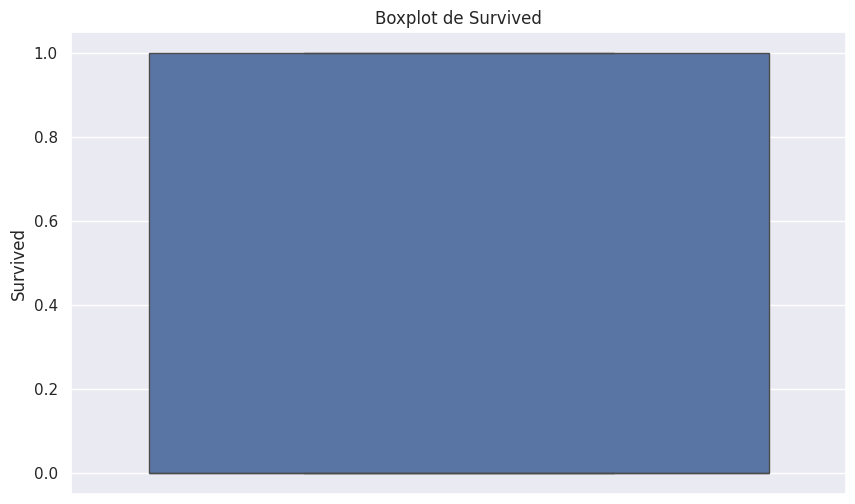

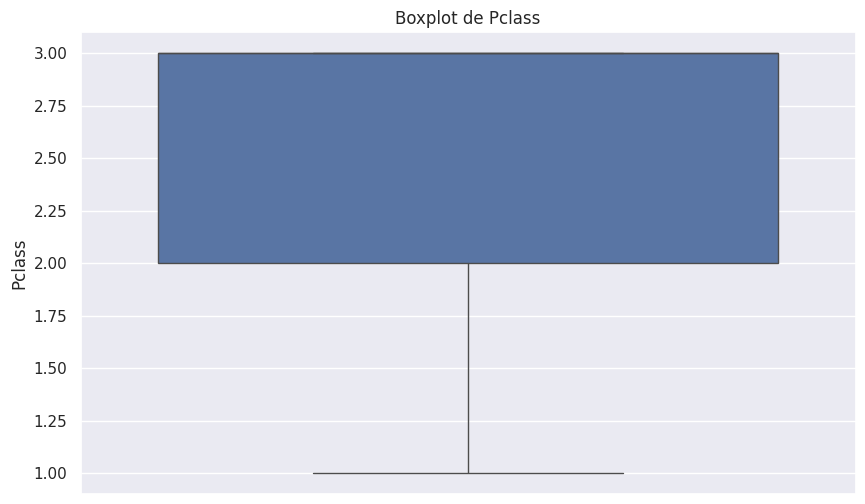

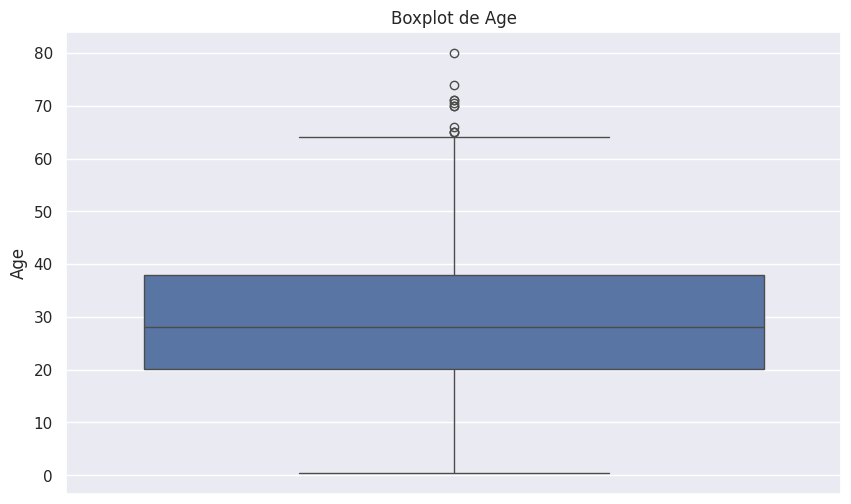

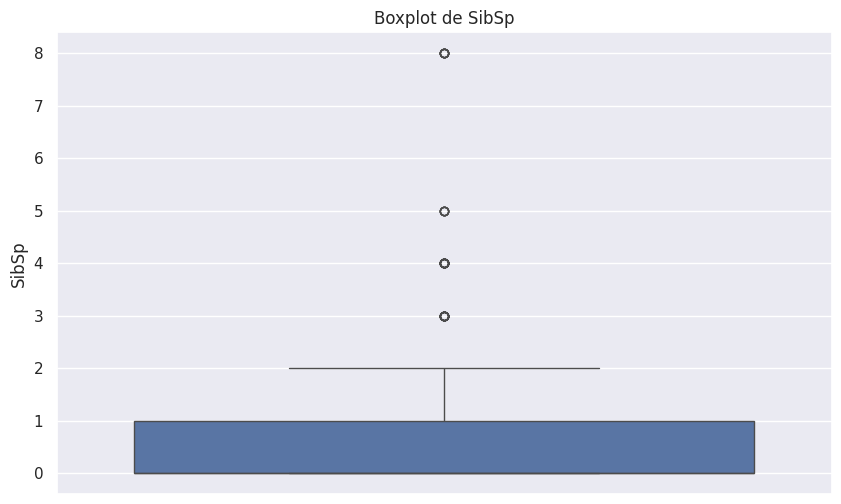

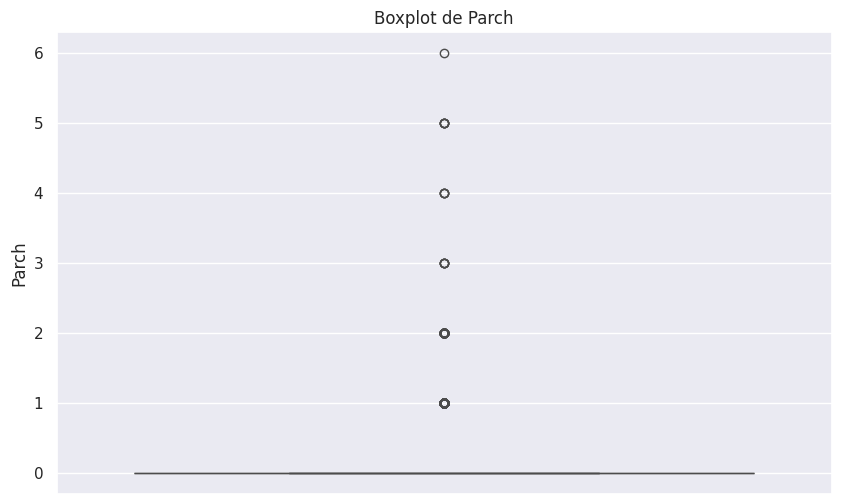

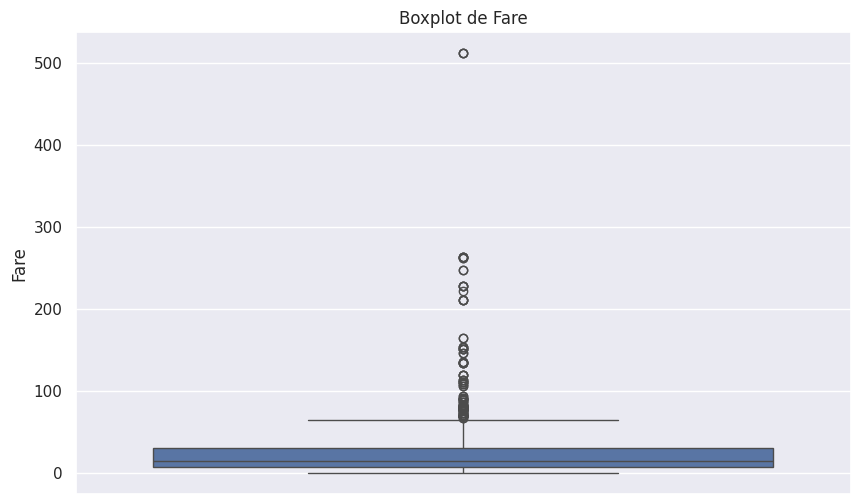

In [0]:
import seaborn 
import matplotlib.pyplot as plt

for variable in list(df.select_dtypes(exclude = 'object').columns):
  plt.figure(figsize=(10,6))
  seaborn.boxplot(data=df[variable])
  plt.title(f'Boxplot de {variable}')
  plt.show()

In [0]:
# df['Age'] = df['Age'].fillna(df['Age'].mean(), inplace=True)

In [0]:
for variable in list(df.select_dtypes(include = 'object').columns):
  print(variable)
  print(df[variable].value_counts())
  print('-----------------------------')

Name
Braund, Mr. Owen Harris                     1
Boulos, Mr. Hanna                           1
Frolicher-Stehli, Mr. Maxmillian            1
Gilinski, Mr. Eliezer                       1
Murdlin, Mr. Joseph                         1
                                           ..
Kelly, Miss. Anna Katherine "Annie Kate"    1
McCoy, Mr. Bernard                          1
Johnson, Mr. William Cahoone Jr             1
Keane, Miss. Nora A                         1
Dooley, Mr. Patrick                         1
Name: Name, Length: 891, dtype: int64
-----------------------------
Sex
male      577
female    314
Name: Sex, dtype: int64
-----------------------------
Ticket
347082      7
CA. 2343    7
1601        7
3101295     6
CA 2144     6
           ..
9234        1
19988       1
2693        1
PC 17612    1
370376      1
Name: Ticket, Length: 681, dtype: int64
-----------------------------
Embarked
S    644
C    168
Q     77
Name: Embarked, dtype: int64
-----------------------------


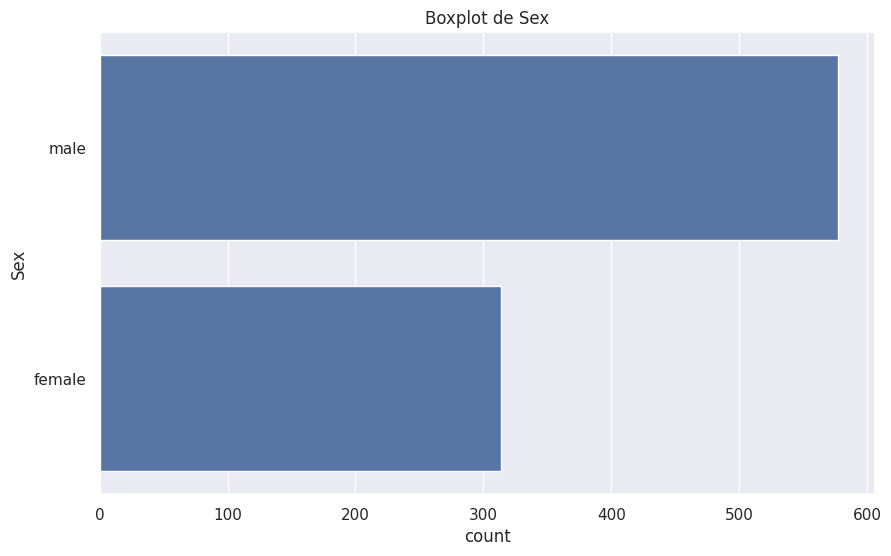

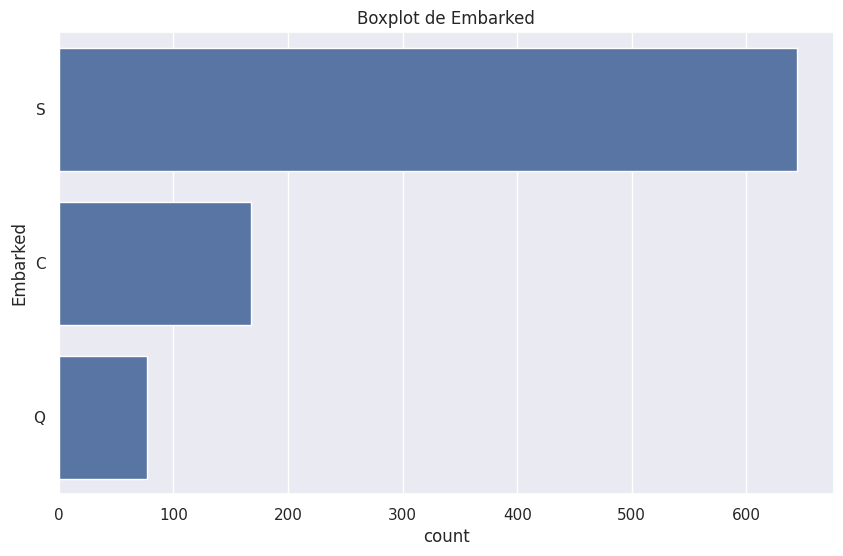

In [0]:
for variable in ['Sex','Embarked']:
  plt.figure(figsize=(10,6))
  seaborn.countplot(data=df[variable])
  plt.title(f'Boxplot de {variable}')
  plt.show()

# Corrélation

In [0]:
numerical_df = df.select_dtypes(include = 'number')
round(numerical_df.corr()*100)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,100.0,-34.0,-8.0,-4.0,8.0,26.0
Pclass,-34.0,100.0,-37.0,8.0,2.0,-55.0
Age,-8.0,-37.0,100.0,-31.0,-19.0,10.0
SibSp,-4.0,8.0,-31.0,100.0,41.0,16.0
Parch,8.0,2.0,-19.0,41.0,100.0,22.0
Fare,26.0,-55.0,10.0,16.0,22.0,100.0


# Encoding

In [0]:
df.select_dtypes(include = 'object').head()

df['Sex'] = df['Sex'].map({'male':0,'female':1})
df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1.0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0.0
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0.0


# Corrélation

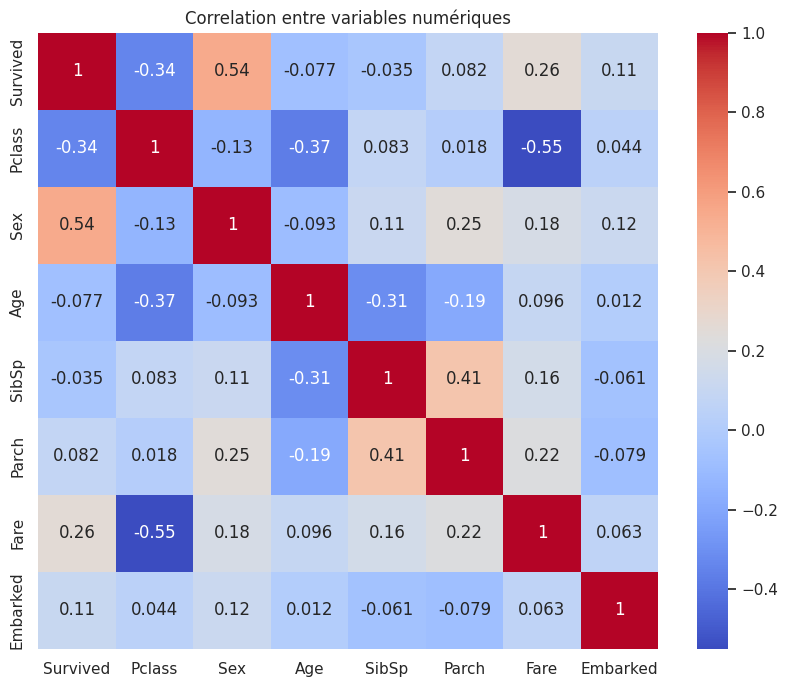

In [0]:
numerical_df = df.select_dtypes(include = 'number')
plt.figure(figsize=(10,8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation entre variables numériques')
display()

# Modélisation

In [0]:
X = numerical_df.drop(columns=['Survived'])
y = numerical_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

# Analyse des variables 

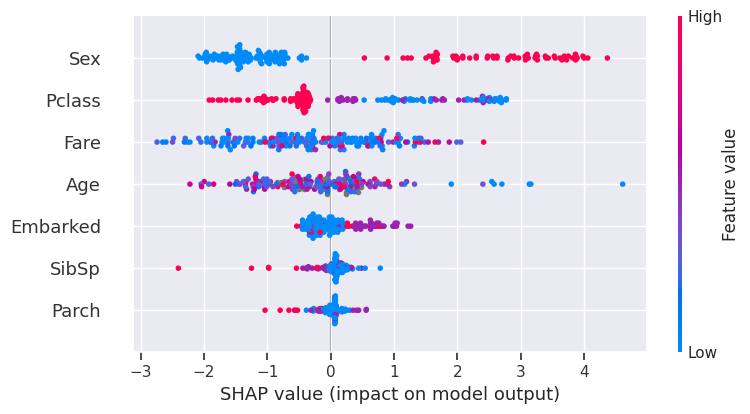

In [0]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test , feature_names=X_test.columns.to_list()) 

# Performances 

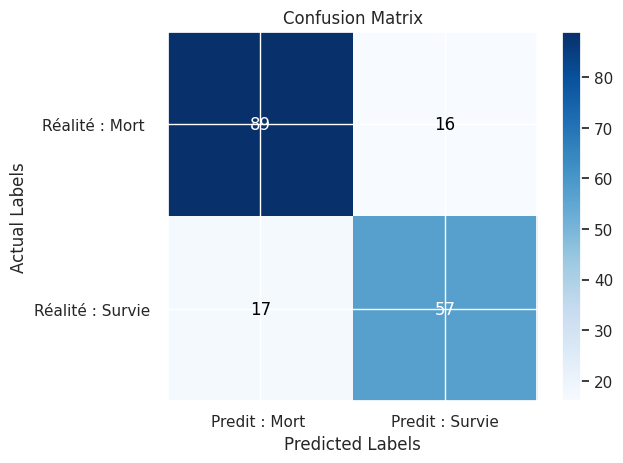

In [0]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
y_pred = xgb_model.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)
plt.imshow(conf_mat, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.xticks([0, 1], ['Predit : Mort ', 'Predit : Survie'])
plt.yticks([0, 1], ['Réalité : Mort  ', 'Réalité : Survie '])
for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        plt.text(j, i, conf_mat[i, j], ha="center", va="center", color="white" if conf_mat[i, j] > conf_mat.max()/2 else "black")
display(plt.show())

In [0]:
accuracy = xgb_model.score(X_test, y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 0.8044692737430168


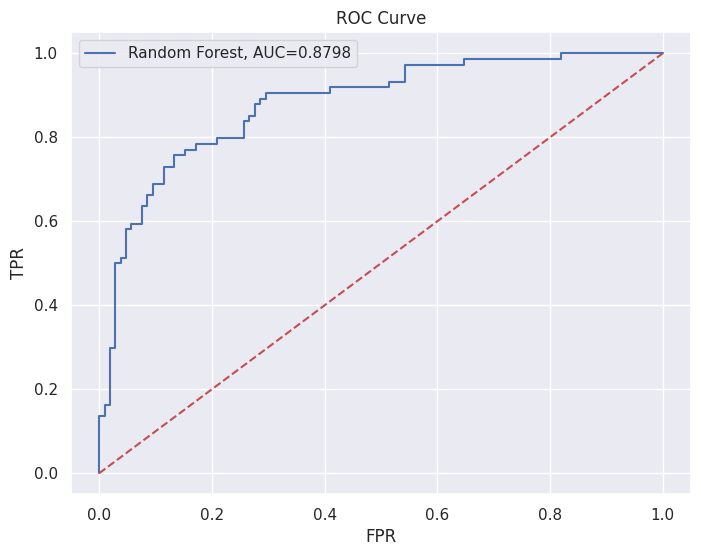

In [0]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve
import seaborn as sns
sns.set()

plt.figure(figsize=(8, 6))


prob = xgb_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, prob)
model_auc = round(auc(fpr, tpr), 4)
plt.plot(fpr,tpr,label="{}, AUC={}".format('Random Forest', model_auc))

random_classifier=np.linspace(0.0, 1.0, 100)
plt.plot(random_classifier, random_classifier, 'r--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Amélioration du modèle

In [0]:
df[df["Survived"]==1]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1.0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0.0
8,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,0.0
9,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,1.0
...,...,...,...,...,...,...,...,...,...,...
875,1,3,"Najib, Miss. Adele Kiamie ""Jane""",1,15.0,0,0,2667,7.2250,1.0
879,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",1,56.0,0,1,11767,83.1583,1.0
880,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",1,25.0,0,1,230433,26.0000,0.0
887,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,0.0


In [0]:
import mlflow
mlflow.autolog(disable=True)

In [0]:
X = numerical_df.drop(columns=['Survived'])

X['Rich'] = X.apply(lambda row: 1 if row['Fare']>=X['Fare'].quantile(0.75) and row['Pclass']==1 and row["Embarked"]==1 else 0, axis=1)
X["Viellard_Femme_Enfant"]= X.apply(lambda row: 1 if row["Age"]>70 or row["Age"]<15 or row["Sex"]==1 else 0, axis=1)

X = X[['Rich','Viellard_Femme_Enfant','Pclass','Embarked', 'Fare']]
y = numerical_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [0]:
import xgboost as xgb
import optuna

def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 1, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'gamma': trial.suggest_float('gamma', 0.01, 10.0),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0)
    }
    xgb_model = xgb.XGBClassifier(**params)
    xgb_model.fit(X_train, y_train)
    accuracy = xgb_model.score(X_train, y_train)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=150)

best_params = study.best_params
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train, y_train)

[I 2025-06-23 14:21:31,457] A new study created in memory with name: no-name-61731c2f-a38a-4e51-b9e6-f22338134974
[I 2025-06-23 14:21:31,487] Trial 0 finished with value: 0.8075842696629213 and parameters: {'max_depth': 2, 'learning_rate': 0.6042129246458982, 'n_estimators': 144, 'gamma': 8.701733174997878, 'subsample': 0.9461469159491478, 'colsample_bytree': 0.9017302174605581, 'reg_alpha': 7.24569491830284, 'reg_lambda': 0.16585717225266164}. Best is trial 0 with value: 0.8075842696629213.
[I 2025-06-23 14:21:31,555] Trial 1 finished with value: 0.8539325842696629 and parameters: {'max_depth': 2, 'learning_rate': 0.7600592429914165, 'n_estimators': 331, 'gamma': 1.2235154464471933, 'subsample': 0.7250849136462537, 'colsample_bytree': 0.9901678157993103, 'reg_alpha': 1.9295305830432055, 'reg_lambda': 6.137645990256143}. Best is trial 1 with value: 0.8539325842696629.
[I 2025-06-23 14:21:31,589] Trial 2 finished with value: 0.7893258426966292 and parameters: {'max_depth': 7, 'learning_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8096091667302234, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0.07152060754036851,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.35812853059585376,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=887, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

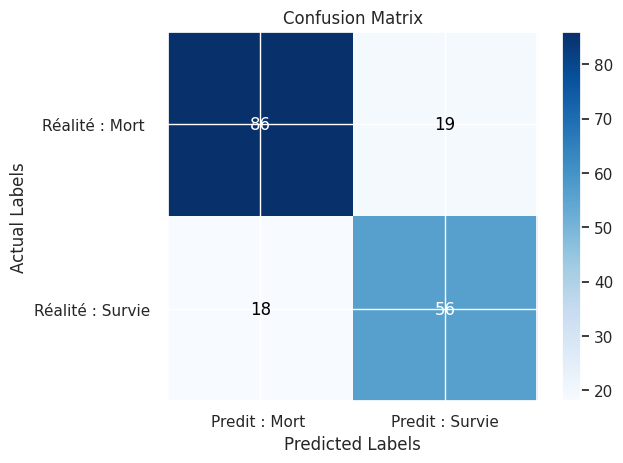

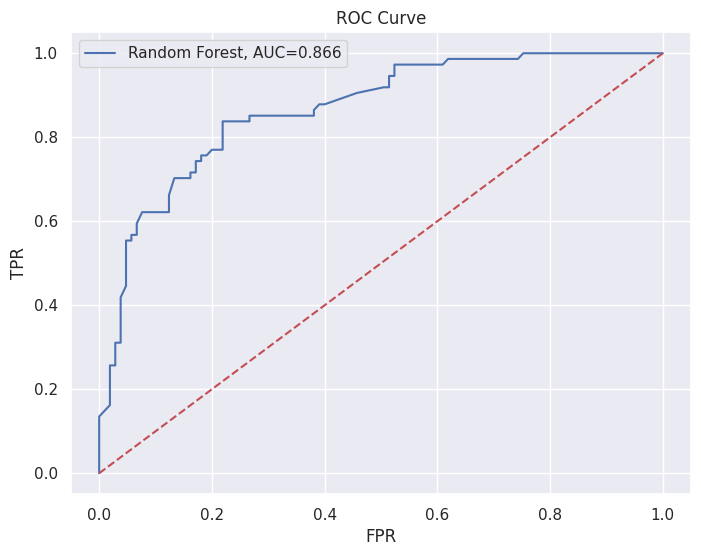

In [0]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
y_pred = xgb_model.predict(X_test)
conf_mat = confusion_matrix(y_test, y_pred)
plt.imshow(conf_mat, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.xticks([0, 1], ['Predit : Mort ', 'Predit : Survie'])
plt.yticks([0, 1], ['Réalité : Mort  ', 'Réalité : Survie '])
for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        plt.text(j, i, conf_mat[i, j], ha="center", va="center", color="white" if conf_mat[i, j] > conf_mat.max()/2 else "black")
display(plt.show())

plt.figure(figsize=(8, 6))


prob = xgb_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, prob)
model_auc = round(auc(fpr, tpr), 4)
plt.plot(fpr,tpr,label="{}, AUC={}".format('Random Forest', model_auc))

random_classifier=np.linspace(0.0, 1.0, 100)
plt.plot(random_classifier, random_classifier, 'r--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

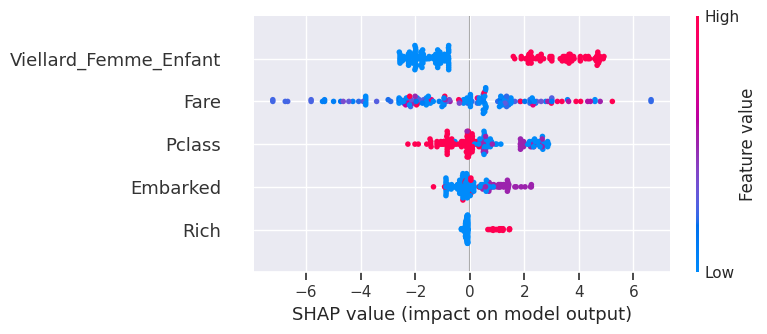

In [0]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test , feature_names=X_test.columns.to_list()) 